<a href="https://colab.research.google.com/github/brave-0001/habit-insight-model/blob/main/habit_insight_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/student_productivity_distraction_dataset_20000.csv')

In [3]:
print(df.shape)

(20000, 18)


In [6]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [7]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']


In [8]:
print(df.dtypes)

student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object


In [9]:
print("\nMissing values:")


Missing values:


In [10]:
print(df.isnull().sum())

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64


In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
features = ['study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
            'social_media_hours', 'exercise_minutes', 'stress_level',
            'breaks_per_day']

In [17]:
X = df[features]
y = df['productivity_score']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)


In [20]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [21]:
print("Decision Tree:")
print(f"  MAE: {mean_absolute_error(y_test, dt_pred):.2f}")
print(f"  R2:  {r2_score(y_test, dt_pred):.2f}")

Decision Tree:
  MAE: 8.38
  R2:  0.58


In [22]:
print("\nRandom Forest:")
print(f"  MAE: {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"  R2:  {r2_score(y_test, rf_pred):.2f}")


Random Forest:
  MAE: 6.18
  R2:  0.79


In [23]:
import joblib

In [24]:
joblib.dump(rf_model, 'habit_model.pkl')

['habit_model.pkl']

In [25]:
print("Model saved!")

Model saved!


In [26]:
import joblib
joblib.dump(rf_model, 'habit_model.pkl')
print("Model saved!")

Model saved!


In [27]:
from google.colab import files
files.download('habit_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import matplotlib.pyplot as plt

In [29]:
import numpy as np

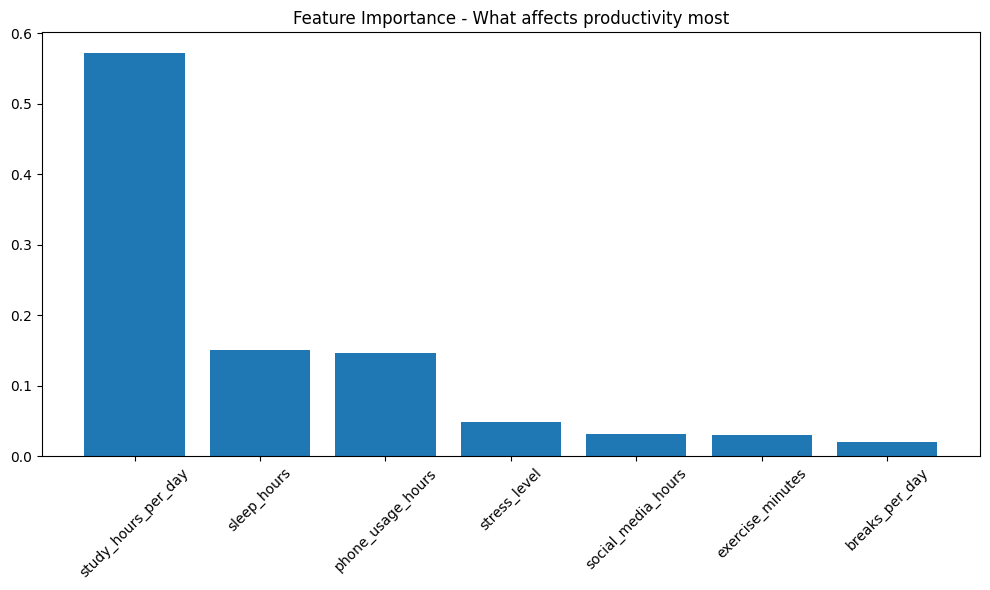

In [30]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.title("Feature Importance - What affects productivity most")
plt.tight_layout()
plt.show()

In [31]:
# Cell 2 - Test the model manually
sample = pd.DataFrame([{
    'study_hours_per_day': 5,
    'sleep_hours': 7,
    'phone_usage_hours': 3,
    'social_media_hours': 2,
    'exercise_minutes': 30,
    'stress_level': 5,
    'breaks_per_day': 3
}])
prediction = rf_model.predict(sample)
print(f"Predicted productivity score: {prediction[0]:.1f}")

Predicted productivity score: 56.2
